In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
samp1 = pd.read_csv(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-24_2026-04-24_14-25-38.csv",
    header=0,
)
samp2 = pd.read_csv(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-24_2026-04-24_14-33-08.csv",
    header=0,
)

In [20]:
samp1.columns

Index(['contract_type', 'symbol', 'description', 'strike', 'expiration_date',
       'mark', 'bid', 'bid_size', 'ask', 'ask_size', 'last', 'last_size',
       'open_interest', 'total_volume', 'delta', 'gamma', 'theta', 'vega',
       'rho', 'volatility', 'theoretical_volatility',
       'theoretical_option_value', 'intrinsic_value', 'extrinsic_value',
       'underlying_price'],
      dtype='object')

In [21]:
samp1.loc[
    (samp1["open_interest"] > 0) & (samp1["total_volume"] > 0),
    ["contract_type", "strike", "open_interest", "total_volume"],
]

,contract_type,strike,open_interest,total_volume
45,CALL,5850.0,9,1
63,CALL,6000.0,1601,3
69,CALL,6050.0,8,1
75,CALL,6100.0,21,7
131,CALL,6430.0,117,70
...,...,...,...,...
665,PUT,7300.0,52,1
669,PUT,7320.0,2,1
681,PUT,7400.0,7,1
685,PUT,7430.0,12,1


In [22]:
samp2.loc[
    (samp1["open_interest"] > 0) & (samp1["total_volume"] > 0),
    ["contract_type", "strike", "open_interest", "total_volume"],
]

,contract_type,strike,open_interest,total_volume
45,CALL,5850.0,9,1
63,CALL,6000.0,1601,3
69,CALL,6050.0,8,1
75,CALL,6100.0,21,7
131,CALL,6430.0,117,70
...,...,...,...,...
665,PUT,7300.0,52,2
669,PUT,7320.0,2,1
681,PUT,7400.0,7,1
685,PUT,7430.0,12,1


In [31]:
compare = samp1["open_interest"] == samp2["open_interest"]
compare.value_counts()

open_interest
True    720
Name: count, dtype: int64

In [25]:
compare = samp1["total_volume"] == samp2["total_volume"]

In [29]:
compare.value_counts()

total_volume
True     555
False    165
Name: count, dtype: int64

## Compare BS prices to actual prices on 0DTE

In [89]:
df = pd.read_csv(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-24_2026-04-24_13-30-26.csv",
    header=0,
)
calls_df = df.loc[(df["contract_type"] == "CALL") & (df["strike"].between(6800, 7400))].reset_index(
    drop=True
)
puts_df = df.loc[(df["contract_type"] == "PUT") & (df["strike"].between(6800, 7400))].reset_index(
    drop=True
)

In [90]:
spot = calls_df.iloc[0]["underlying_price"]

In [91]:
calls_df["mark"]

0      331.45
1      326.50
2      321.60
3      316.50
4      311.60
        ...  
112      0.03
113      0.03
114      0.13
115      0.03
116      0.03
Name: mark, Length: 117, dtype: float64

In [92]:
calls_df.shape

(117, 25)

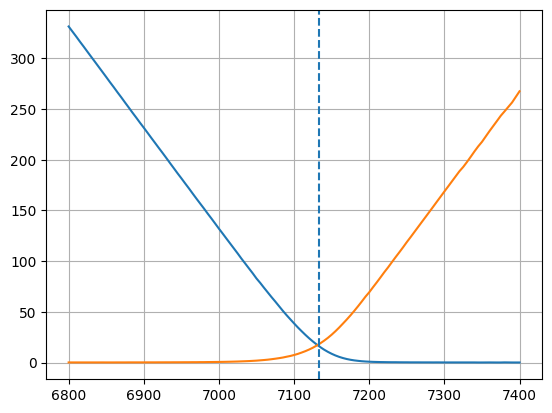

In [93]:
plt.figure()
plt.plot(calls_df["strike"], calls_df["mark"], label="calls")
plt.plot(puts_df["strike"], puts_df["mark"], label="puts")
plt.grid(True)
plt.axvline(spot, linestyle="--")

In [97]:
puts_df.loc[puts_df["strike"].isin([7200, 7300])]

,contract_type,symbol,description,strike,expiration_date,mark,bid,bid_size,ask,ask_size,...,gamma,theta,vega,rho,volatility,theoretical_volatility,theoretical_option_value,intrinsic_value,extrinsic_value,underlying_price
80,PUT,SPXW 260424P07200000,SPXW 04/24/2026 7200.00 P,7200.0,2026-04-24,69.3,68.2,19,70.4,1,...,0.001,-8.683,0.252,-0.176,14.901,29.0,100.283,66.46,2.58,7133.54
100,PUT,SPXW 260424P07300000,SPXW 04/24/2026 7300.00 P,7300.0,2026-04-24,168.7,167.4,12,170.0,2,...,0.000,-8.107,0.036,-0.183,20.370,29.0,199.707,166.46,25.03,7133.54


In [98]:
(168.7 - 69.3) / (7300 - 7200)

0.9939999999999999

In [95]:
puts_df.loc[calls_df["strike"].isin([6900, 7000])]

,contract_type,symbol,description,strike,expiration_date,mark,bid,bid_size,ask,ask_size,...,gamma,theta,vega,rho,volatility,theoretical_volatility,theoretical_option_value,intrinsic_value,extrinsic_value,underlying_price
20,PUT,SPXW 260424P06900000,SPXW 04/24/2026 6900.00 P,6900.0,2026-04-24,0.13,0.10,304,0.15,162,...,0.000,-0.55,0.143,-0.003,26.707,29.0,0.55,-233.54,233.69,7133.54
40,PUT,SPXW 260424P07000000,SPXW 04/24/2026 7000.00 P,7000.0,2026-04-24,0.57,0.55,92,0.60,142,...,0.002,-3.60,0.613,-0.017,21.958,29.0,3.60,-133.54,134.14,7133.54


In [96]:
(0.57 - 0.13) / (7000 - 6900)

0.004399999999999999

In [170]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq


def _bs_price(S, K, T, r, sigma, call=True):
    if T <= 0:
        return max(0.0, (S - K) if call else (K - S))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if call:
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


# def implied_vol(price, S, K, hours_to_expiry, r=0.0, call=True):
#     # Convert hours to year fraction (trading-day basis ~252 days * 6.5h)
#     T = hours_to_expiry / (252 * 6.5)

#     # No-arb bounds (helps bracketing)
#     intrinsic = max(0.0, (S - K) if call else (K - S))
#     price = max(price, intrinsic + 1e-12)

#     f = lambda sigma: _bs_price(S, K, T, r, sigma, call) - price

#     # Robust bracket for 0DTE (vol can be very high)
#     return brentq(f, 1e-6, 10.0)  # 0.0001% to 500% vol


def implied_vol(price, opt_ask, opt_bid, S, K, days_to_expiry, r=0.0, call=True, max_vol=10.0):
    # T = hours_to_expiry / (252 * 6.5)
    T = days_to_expiry / 365.0
    intrinsic = max(0.0, (S - K) if call else (K - S))
    # F = K + exp(r * T) * (call_mid - put_mid)/
    price = max(price, intrinsic + 1e-12)

    f = lambda sigma: _bs_price(S, K, T, r, sigma, call) - price
    return brentq(f, 1e-6, max_vol) * 100

In [297]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq


# --- Black-76 (forward-based) pricing ---
def _b76_price(F, K, T, r, sigma, call=True):
    if T <= 0:
        return max(0.0, (F - K) if call else (K - F)) * np.exp(-r * T)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    df = np.exp(-r * T)

    if call:
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


# --- Forward from put-call parity ---
def forward_price(K, call_bid, call_ask, put_bid, put_ask, r, T):
    call_mid = 0.5 * (call_bid + call_ask)
    put_mid = 0.5 * (put_bid + put_ask)
    return K + np.exp(r * T) * (call_mid - put_mid)


# --- Implied vol using forward ---
def implied_vol(
    F, price, call_bid, call_ask, put_bid, put_ask, K, days_to_expiry, r=0.0, call=True, max_vol=5.0
):
    T = days_to_expiry / 365.0

    # compute forward
    F = forward_price(K, call_bid, call_ask, put_bid, put_ask, r, T)

    # intrinsic in forward space (discounted)
    intrinsic = max(0.0, (F - K) if call else (K - F)) * np.exp(-r * T)
    price = max(price, intrinsic + 1e-12)

    f = lambda sigma: _b76_price(F, K, T, r, sigma, call) - price

    return brentq(f, 1e-6, max_vol) * 100

In [143]:
calls_df["bs_vol"] = calls_df.apply(
    lambda row: implied_vol(
        row.mark,
        row.bid,
        row.ask,
        row.underlying_price,
        row.strike,
        6.5,
        r=0.0,
        call=(row.contract_type == "CALL"),
        max_vol=50.0,
    ),
    axis=1,
)

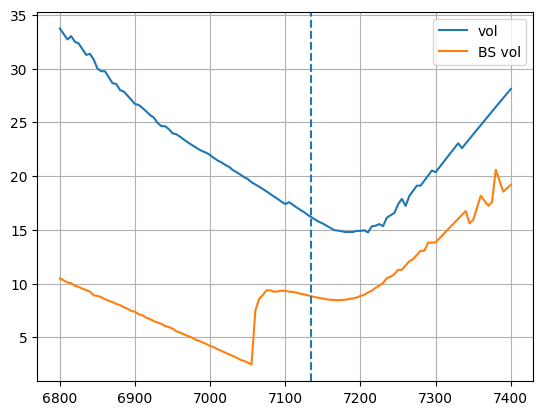

In [144]:
plt.figure()
plt.plot(calls_df["strike"], calls_df["volatility"], label="vol")
plt.plot(calls_df["strike"], calls_df["bs_vol"], label="BS vol")
plt.grid(True)
plt.legend()
plt.axvline(spot, linestyle="--")

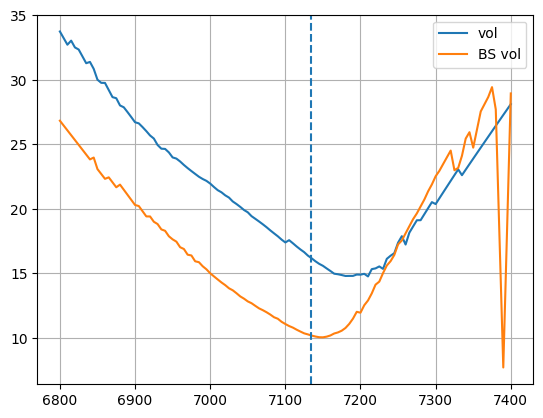

In [145]:
puts_df["bs_vol"] = puts_df.apply(
    lambda row: implied_vol(
        row.mark,
        row.underlying_price,
        row.strike,
        6.5,
        r=0.0,
        call=(row.contract_type == "CALL"),
        max_vol=50.0,
    ),
    axis=1,
)
plt.figure()
plt.plot(puts_df["strike"], puts_df["volatility"], label="vol")
plt.plot(puts_df["strike"], puts_df["bs_vol"], label="BS vol")
plt.grid(True)
plt.legend()
plt.axvline(spot, linestyle="--")

In [146]:
may_chain_df = pd.read_csv(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-05-22_2026-04-22_19-39-03.csv",
    header=0,
)

In [147]:
may_chain_calls = may_chain_df.loc[(may_chain_df["contract_type"] == "CALL")].reset_index(drop=True)
may_chain_puts = may_chain_df.loc[(may_chain_df["contract_type"] == "PUT")].reset_index(drop=True)

In [286]:
cols = ["strike", "mark", "ask", "bid", "volatility", "underlying_price"]
df = may_chain_calls[cols].merge(
    may_chain_puts[cols], on="strike", how="inner", suffixes=("_call", "_put")
)

In [287]:
df.head()

,strike,mark_call,ask_call,bid_call,volatility_call,underlying_price_call,mark_put,ask_put,bid_put,volatility_put,underlying_price_put
0,2600.0,4529.75,4540.3,4519.2,100.855,7128.41,0.08,0.15,0.00,100.855,7128.41
1,2800.0,4330.55,4340.9,4320.2,95.523,7128.41,0.10,0.20,0.00,95.523,7128.41
2,3000.0,4131.35,4141.6,4121.1,90.127,7128.41,0.13,0.20,0.05,90.127,7128.41
3,3200.0,3932.70,3942.5,3922.9,84.793,7128.41,0.15,0.20,0.10,84.793,7128.41
4,3400.0,3732.80,3743.3,3722.3,81.111,7128.41,0.22,0.30,0.15,81.111,7128.41


In [293]:
# pick strike closest to spot (ATM)
atm_row = df.iloc[(df["strike"] - df["underlying_price_call"]).abs().argmin()]

T = 30.25 / 365.0

F = atm_row["strike"] + np.exp(0.0 * T) * (atm_row["mark_call"] - atm_row["mark_put"])

In [298]:
df["bs_call_vol"] = df.apply(
    lambda row: implied_vol(
        F,
        row.mark_call,
        row.bid_call,
        row.ask_call,
        row.bid_put,
        row.ask_put,
        row.strike,
        30.25,
        r=0.0,
        call=True,
        max_vol=20.0,
    ),
    axis=1,
)
df["bs_put_vol"] = df.apply(
    lambda row: implied_vol(
        F,
        row.mark_put,
        row.bid_call,
        row.ask_call,
        row.bid_put,
        row.ask_put,
        row.strike,
        30.25,
        r=0.0,
        call=False,
        max_vol=20.0,
    ),
    axis=1,
)

In [299]:
filtered_df = df.loc[(df["strike"] < 8500) & (df["strike"] > 6000)]

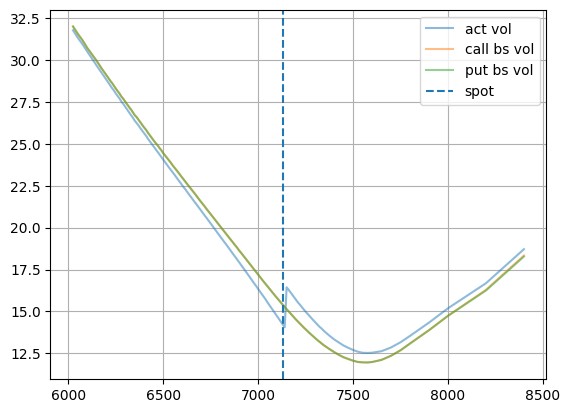

In [300]:
plt.figure()


# plt.plot(filtered_df['strike'], filtered_df['volatility_put'], label='act put vol', alpha=0.5)
plt.plot(filtered_df["strike"], filtered_df["volatility_call"], label="act vol", alpha=0.5)
plt.plot(filtered_df["strike"], filtered_df["bs_call_vol"], label="call bs vol", alpha=0.5)
plt.plot(filtered_df["strike"], filtered_df["bs_put_vol"], label="put bs vol", alpha=0.5)
plt.axvline(spot, linestyle="--", label="spot")
plt.grid(True)
plt.legend()

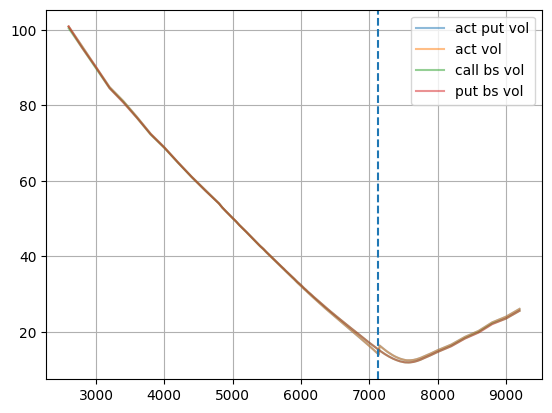

In [283]:
plt.figure()


plt.plot(df["strike"], df["volatility_put"], label="act put vol", alpha=0.5)
plt.plot(df["strike"], df["volatility_call"], label="act vol", alpha=0.5)
plt.plot(df["strike"], df["bs_call_vol"], label="call bs vol", alpha=0.5)
plt.plot(df["strike"], df["bs_put_vol"], label="put bs vol", alpha=0.5)
plt.grid(True)
plt.legend()
plt.axvline(spot, linestyle="--")

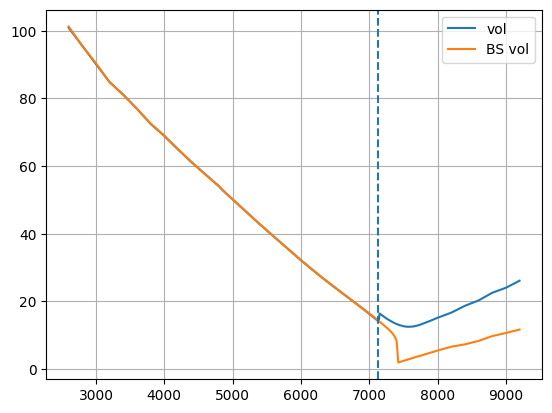

In [169]:
may_chain_puts["bs_vol"] = may_chain_puts.apply(
    lambda row: implied_vol(
        row.mark,
        row.underlying_price,
        row.strike,
        30,
        r=0,
        call=(row.contract_type == "CALL"),
        max_vol=100.0,
    ),
    axis=1,
)
plt.figure()
plt.plot(may_chain_puts["strike"], may_chain_puts["volatility"], label="vol")
# plt.plot(may_chain_puts['strike'], may_chain_puts['theoretical_volatility'], label='theo vol')
plt.plot(may_chain_puts["strike"], may_chain_puts["bs_vol"], label="BS vol")
plt.grid(True)
plt.legend()
plt.axvline(spot, linestyle="--")

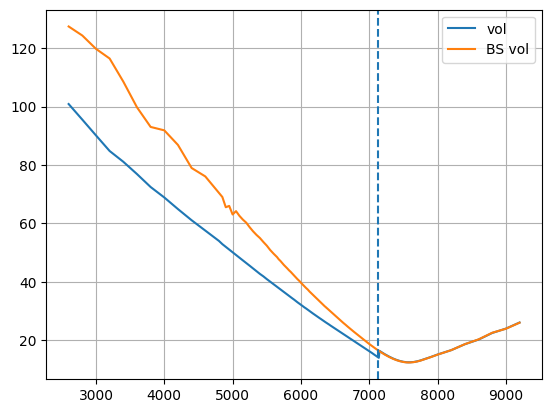

In [168]:
may_chain_calls["bs_vol"] = may_chain_calls.apply(
    lambda row: implied_vol(
        row.mark,
        row.underlying_price,
        row.strike,
        30,
        r=0,
        call=(row.contract_type == "CALL"),
        max_vol=50.0,
    ),
    axis=1,
)
plt.figure()
plt.plot(may_chain_calls["strike"], may_chain_calls["volatility"], label="vol")
# plt.plot(may_chain_puts['strike'], may_chain_puts['theoretical_volatility'] * 100, label='theo vol')
plt.plot(may_chain_calls["strike"], may_chain_calls["bs_vol"], label="BS vol")
plt.grid(True)
plt.legend()
plt.axvline(spot, linestyle="--")